In [ ]:
!pip install -q kornia kornia-rs
!pip install -q opencv-python-headless matplotlib numpy torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 131.4 MB/s eta 0:00:00


In [ ]:
import torch
import kornia as K
import kornia.feature as KF

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

matcher = KF.LoFTR(pretrained='outdoor').to(device).eval()
print("LoFTR model loaded")

Using device: cuda
Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:03<00:00, 12.7MB/s]


LoFTR model loaded


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
dataset_dir = '/content/drive/MyDrive/Dataset Rgb and mine/rgb'
files = sorted(os.listdir(dataset_dir))
print(f"Total images: {len(files)}")
print(files[:5])

Total images: 613
['1305031452.791720.png', '1305031452.823674.png', '1305031452.859642.png', '1305031452.891726.png', '1305031452.923715.png']


In [ ]:
import cv2
import numpy as np

def load_gray_tensor(filename):
    path = os.path.join(dataset_dir, filename)
    img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    tensor = torch.from_numpy(img_gray).float()[None, None] / 255.0
    return tensor.to(device), img_gray

img1_tensor, img1_gray = load_gray_tensor(files[0])
img2_tensor, img2_gray = load_gray_tensor(files[1])

print("img1_tensor shape:", img1_tensor.shape)
print("img2_tensor shape:", img2_tensor.shape)

img1_tensor shape: torch.Size([1, 1, 480, 640])
img2_tensor shape: torch.Size([1, 1, 480, 640])


In [ ]:
input_dict = {"image0": img1_tensor, "image1": img2_tensor}

with torch.no_grad():
    correspondences = matcher(input_dict)

mkpts_0 = correspondences['keypoints0'].cpu().numpy()
mkpts_1 = correspondences['keypoints1'].cpu().numpy()
confidence = correspondences['confidence'].cpu().numpy()

print("Matched keypoints:", mkpts_0.shape)
print("Sample confidence scores:", confidence[:5])

Matched keypoints: (2996, 2)
Sample confidence scores: [0.20497465 0.44064647 0.60748106 0.34890014 0.72310853]


In [ ]:
F, mask = cv2.findFundamentalMat(mkpts_0, mkpts_1, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)

inliers = int(mask.sum()) if mask is not None else 0
total_matches = len(mkpts_0)
inlier_ratio = inliers / total_matches if total_matches > 0 else 0

print("Matches:", total_matches)
print("Inliers:", inliers)
print("Inlier ratio: {:.2%}".format(inlier_ratio))

Matches: 2996
Inliers: 2058
Inlier ratio: 68.69%


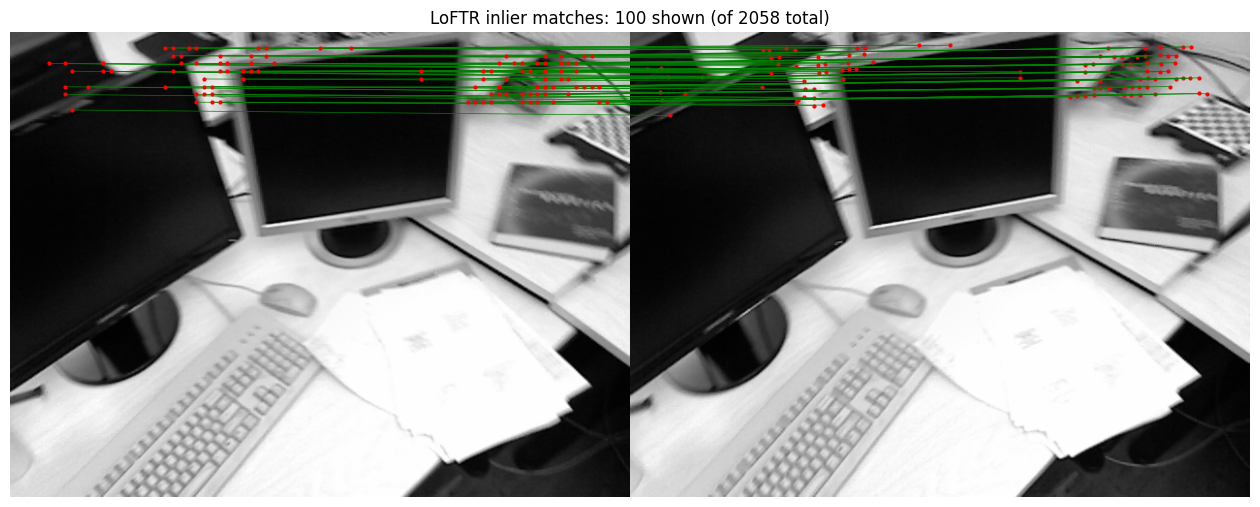

In [ ]:
import matplotlib.pyplot as plt

h1, w1 = img1_gray.shape[:2]
h2, w2 = img2_gray.shape[:2]
canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
canvas[:h1, :w1] = cv2.cvtColor(img1_gray, cv2.COLOR_GRAY2RGB)
canvas[:h2, w1:w1+w2] = cv2.cvtColor(img2_gray, cv2.COLOR_GRAY2RGB)

inlier_idx = np.where(mask.ravel() == 1)[0]
draw_idx = inlier_idx[:100]

plt.figure(figsize=(16, 8))
plt.imshow(canvas)
for idx in draw_idx:
    x1, y1 = mkpts_0[idx]
    x2, y2 = mkpts_1[idx]
    plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
    plt.plot(x1, y1, 'ro', markersize=2)
    plt.plot(x2 + w1, y2, 'ro', markersize=2)
plt.title(f"LoFTR inlier matches: {len(draw_idx)} shown (of {inliers} total)")
plt.axis('off')
plt.show()

In [ ]:
import time
import pandas as pd

results_loftr = []
start_time = time.time()

for i in range(len(files) - 1):
    img1_tensor, _ = load_gray_tensor(files[i])
    img2_tensor, _ = load_gray_tensor(files[i+1])

    input_dict = {"image0": img1_tensor, "image1": img2_tensor}

    with torch.no_grad():
        correspondences = matcher(input_dict)

    mkpts_0 = correspondences['keypoints0'].cpu().numpy()
    mkpts_1 = correspondences['keypoints1'].cpu().numpy()

    num_matches = len(mkpts_0)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(mkpts_0, mkpts_1, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    results_loftr.append({
        'pair_index': i,
        'frame1': files[i],
        'frame2': files[i+1],
        'num_matches': num_matches,
        'num_inliers': num_inliers,
        'inlier_ratio': inlier_ratio
    })

    if i % 50 == 0:
        elapsed = time.time() - start_time
        print(f"Pair {i}/{len(files)-1} done | elapsed: {elapsed:.1f}s")

print("Batch run complete. Total time: {:.1f}s".format(time.time() - start_time))

Pair 0/612 done | elapsed: 0.4s
Pair 50/612 done | elapsed: 28.2s
Pair 100/612 done | elapsed: 46.9s
Pair 150/612 done | elapsed: 66.4s
Pair 200/612 done | elapsed: 85.0s
Pair 250/612 done | elapsed: 103.1s
Pair 300/612 done | elapsed: 120.9s
Pair 350/612 done | elapsed: 139.5s
Pair 400/612 done | elapsed: 158.1s
Pair 450/612 done | elapsed: 176.4s
Pair 500/612 done | elapsed: 194.3s
Pair 550/612 done | elapsed: 212.5s
Pair 600/612 done | elapsed: 231.1s
Batch run complete. Total time: 235.4s


In [ ]:
import pandas as pd
df_loftr = pd.DataFrame(results_loftr)
csv_path = '/content/drive/MyDrive/Dataset Rgb and mine/loftr_consecutive_pairs.csv'
df_loftr.to_csv(csv_path, index=False)

print("Saved to:", csv_path)
print(df_loftr.head())
print()
print("Summary stats:")
print(df_loftr[['num_matches', 'num_inliers', 'inlier_ratio']].describe())

Saved to: /content/drive/MyDrive/Dataset Rgb and mine/loftr_consecutive_pairs.csv
   pair_index                 frame1                 frame2  num_matches  \
0           0  1305031452.791720.png  1305031452.823674.png         2996   
1           1  1305031452.823674.png  1305031452.859642.png         3079   
2           2  1305031452.859642.png  1305031452.891726.png         3076   
3           3  1305031452.891726.png  1305031452.923715.png         2794   
4           4  1305031452.923715.png  1305031452.959701.png         3184   

   num_inliers  inlier_ratio  
0         2058      0.686916  
1         2149      0.697954  
2         2220      0.721717  
3         1730      0.619184  
4         2178      0.684045  

Summary stats:
       num_matches  num_inliers  inlier_ratio
count   612.000000   612.000000    612.000000
mean   3634.197712  2847.862745      0.778442
std     316.540374   495.179341      0.083291
min    2379.000000   866.000000      0.336834
25%    3467.000000  2554.2500

In [ ]:
robustness_dir_new = '/content/drive/MyDrive/Dataset Rgb and mine'
# If this folder doesn't exist in the new account's Drive, we'll need to share it from your original account first
print(os.path.exists(robustness_dir_new))

True


In [ ]:
import cv2
import numpy as np

def load_gray_tensor_resized(filename, max_dim=1280):
    path = os.path.join(robustness_dir_new, filename)
    img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    h, w = img_gray.shape[:2]
    scale = max_dim / max(h, w)
    if scale < 1:
        new_w, new_h = int(w * scale), int(h * scale)
        img_gray = cv2.resize(img_gray, (new_w, new_h), interpolation=cv2.INTER_AREA)

    tensor = torch.from_numpy(img_gray).float()[None, None] / 255.0
    return tensor.to(device)

portrait_trolley_t = load_gray_tensor_resized('portrait-trolley.jpeg')
trolley_45_rotated_t = load_gray_tensor_resized('trolley-45-rotated.jpeg')
zoomed_trolley_t = load_gray_tensor_resized('zoomed-trolley.jpeg')

portrait_wall_t = load_gray_tensor_resized('portrait-wall.jpeg')
rotated_90_wall_t = load_gray_tensor_resized('90-rotated-wall.jpeg')
zoomed_wall_t = load_gray_tensor_resized('zoomed-wall.jpeg')

print("All robustness images loaded and resized")
print("portrait_trolley_t:", portrait_trolley_t.shape)
print("portrait_wall_t:", portrait_wall_t.shape)

All robustness images loaded and resized
portrait_trolley_t: torch.Size([1, 1, 1280, 960])
portrait_wall_t: torch.Size([1, 1, 1280, 960])


In [ ]:
def run_loftr_test(img1_tensor, img2_tensor, label):
    input_dict = {"image0": img1_tensor, "image1": img2_tensor}

    with torch.no_grad():
        correspondences = matcher(input_dict)

    mkpts_0 = correspondences['keypoints0'].cpu().numpy()
    mkpts_1 = correspondences['keypoints1'].cpu().numpy()

    num_matches = len(mkpts_0)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(mkpts_0, mkpts_1, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    print(f"--- {label} ---")
    print(f"Matches: {num_matches} | Inliers: {num_inliers} | Inlier ratio: {inlier_ratio:.2%}")
    print()

    return {
        'test': label,
        'matches': num_matches,
        'inliers': num_inliers,
        'inlier_ratio': inlier_ratio
    }

loftr_robustness_results = []

loftr_robustness_results.append(run_loftr_test(portrait_trolley_t, trolley_45_rotated_t, "portrait-trolley vs trolley-45-rotated"))
loftr_robustness_results.append(run_loftr_test(portrait_trolley_t, zoomed_trolley_t, "portrait-trolley vs zoomed-trolley"))
loftr_robustness_results.append(run_loftr_test(portrait_wall_t, rotated_90_wall_t, "portrait-wall vs 90-rotated-wall"))
loftr_robustness_results.append(run_loftr_test(portrait_wall_t, zoomed_wall_t, "portrait-wall vs zoomed-wall"))

--- portrait-trolley vs trolley-45-rotated ---
Matches: 5817 | Inliers: 3190 | Inlier ratio: 54.84%

--- portrait-trolley vs zoomed-trolley ---
Matches: 5116 | Inliers: 3118 | Inlier ratio: 60.95%

--- portrait-wall vs 90-rotated-wall ---
Matches: 12449 | Inliers: 11349 | Inlier ratio: 91.16%

--- portrait-wall vs zoomed-wall ---
Matches: 6446 | Inliers: 4981 | Inlier ratio: 77.27%



In [ ]:
loftr_robustness_df = pd.DataFrame(loftr_robustness_results)
loftr_robustness_df.to_csv('/content/drive/MyDrive/loftr_robustness_tests.csv', index=False)
print(loftr_robustness_df)

                                     test  matches  inliers  inlier_ratio
0  portrait-trolley vs trolley-45-rotated     5817     3190      0.548393
1      portrait-trolley vs zoomed-trolley     5116     3118      0.609461
2        portrait-wall vs 90-rotated-wall    12449    11349      0.911639
3            portrait-wall vs zoomed-wall     6446     4981      0.772727
